# Experiment 4: Binary Classification using Linear and Kernel-Based Models

# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

import time

# 2. Load Dataset

In [2]:
df = pd.read_csv("spambase.csv")
df.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


# 3. Basic Dataset Inspection

In [3]:
print("Shape:", df.shape)

Shape: (4601, 58)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

In [5]:
df.isnull().sum().sum()

np.int64(0)

# 4. Exploratory Data Analysis

In [6]:
target_col = df.columns[-1]
df[target_col].value_counts()

class
0    2788
1    1813
Name: count, dtype: int64

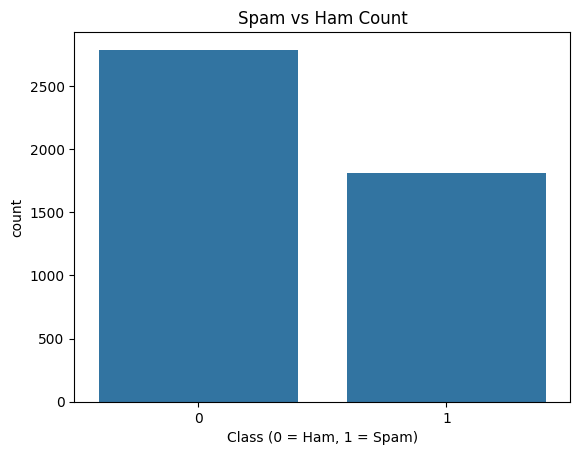

In [7]:
sns.countplot(x=df[target_col])
plt.title("Spam vs Ham Count")
plt.xlabel("Class (0 = Ham, 1 = Spam)")
plt.show()

In [8]:
df.describe()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,...,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,0.104553,0.213015,0.280656,0.065425,0.312223,0.095901,0.114208,0.105295,0.090067,0.239413,...,0.038575,0.139030,0.016976,0.269071,0.075811,0.044238,5.191515,52.172789,283.289285,0.394045
std,0.305358,1.290575,0.504143,1.395151,0.672513,0.273824,0.391441,0.401071,0.278616,0.644755,...,0.243471,0.270355,0.109394,0.815672,0.245882,0.429342,31.729449,194.891310,606.347851,0.488698
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.588000,6.000000,35.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.065000,0.000000,0.000000,0.000000,0.000000,2.276000,15.000000,95.000000,0.000000
75%,0.000000,0.000000,0.420000,0.000000,0.380000,0.000000,0.000000,0.000000,0.000000,0.160000,...,0.000000,0.188000,0.000000,0.315000,0.052000,0.000000,3.706000,43.000000,266.000000,1.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000,1.000000


In [9]:
corr = df.corr(numeric_only=True)

corr_pairs = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

corr_pairs = corr_pairs.stack().reset_index()
corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']

corr_pairs['Absolute Correlation'] = corr_pairs['Correlation'].abs()

top_corr = corr_pairs.sort_values(
    'Absolute Correlation',
    ascending=False
).head(10)

top_corr[['Feature 1', 'Feature 2', 'Correlation']]

,Feature 1,Feature 2,Correlation
1303,word_freq_857,word_freq_415,0.996066
1309,word_freq_857,word_freq_direct,0.848021
1358,word_freq_415,word_freq_direct,0.845359
1275,word_freq_telnet,word_freq_857,0.737555
1277,word_freq_telnet,word_freq_415,0.735187
1305,word_freq_857,word_freq_technology,0.729750
1354,word_freq_415,word_freq_technology,0.727119
1283,word_freq_telnet,word_freq_direct,0.699918
1279,word_freq_telnet,word_freq_technology,0.677790
1403,word_freq_technology,word_freq_direct,0.674249


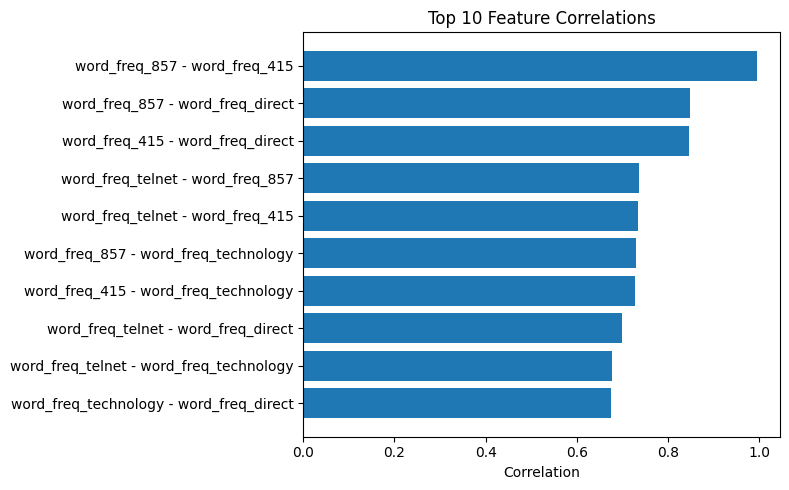

In [10]:
plt.figure(figsize=(8, 5))

labels = top_corr['Feature 1'] + ' - ' + top_corr['Feature 2']

plt.barh(labels, top_corr['Correlation'])
plt.xlabel('Correlation')
plt.title('Top 10 Feature Correlations')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 5. Data Preprocessing

In [11]:
X = df.drop(columns=[target_col])
y = df[target_col]

print(X.shape)
print(y.shape)

(4601, 57)
(4601,)


# 6. Train-Test Split and Feature Scaling

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape, X_test_scaled.shape)

(3680, 57) (921, 57)


# 7. Baseline Logistic Regression

In [13]:
log_reg = LogisticRegression(max_iter=1000)

start = time.time()
log_reg.fit(X_train_scaled, y_train)
log_reg_train_time = time.time() - start

y_pred = log_reg.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Training Time:", log_reg_train_time)

Accuracy: 0.9294245385450597
Precision: 0.9209039548022598
Recall: 0.8980716253443526
F1 Score: 0.9093444909344491
Training Time: 0.019826889038085938


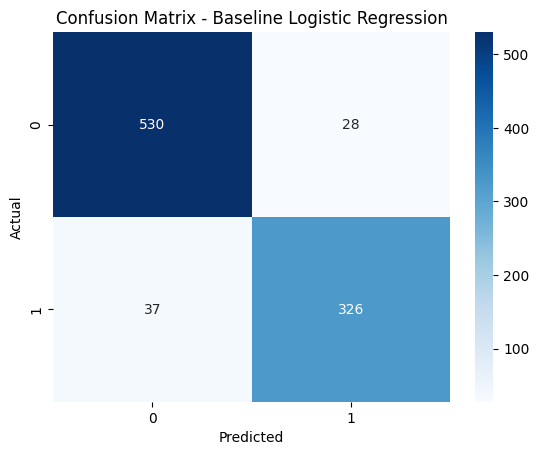

In [14]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Baseline Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94       558
           1       0.92      0.90      0.91       363

    accuracy                           0.93       921
   macro avg       0.93      0.92      0.93       921
weighted avg       0.93      0.93      0.93       921



# 8. Logistic Regression Hyperparameter Tuning

In [16]:
param_grid_log_reg = [
    {"penalty": ["l1"], "C": [0.01, 0.1, 1, 10, 100], "solver": ["liblinear", "saga"]},
    {"penalty": ["l2"], "C": [0.01, 0.1, 1, 10, 100], "solver": ["liblinear", "saga"]},
]

grid_log_reg = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid_log_reg,
    cv=5,
    scoring="accuracy"
)

grid_log_reg.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_log_reg.best_params_)
print("Best CV Accuracy:", grid_log_reg.best_score_)

c:\Users\farih\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\farih\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\farih\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\farih\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\farih\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the 

Best Parameters: {'C': 10, 'penalty': 'l1', 'solver': 'saga'}
Best CV Accuracy: 0.923913043478261


c:\Users\farih\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


# 9. Tuned Logistic Regression Evaluation

In [17]:
best_log_reg = grid_log_reg.best_estimator_

start = time.time()
best_log_reg.fit(X_train_scaled, y_train)
best_log_reg_train_time = time.time() - start

y_pred_best_log_reg = best_log_reg.predict(X_test_scaled)

log_reg_accuracy = accuracy_score(y_test, y_pred_best_log_reg)
log_reg_precision = precision_score(y_test, y_pred_best_log_reg)
log_reg_recall = recall_score(y_test, y_pred_best_log_reg)
log_reg_f1 = f1_score(y_test, y_pred_best_log_reg)

print("Accuracy:", log_reg_accuracy)
print("Precision:", log_reg_precision)
print("Recall:", log_reg_recall)
print("F1 Score:", log_reg_f1)
print("Training Time:", best_log_reg_train_time)

Accuracy: 0.9305103148751357
Precision: 0.9211267605633803
Recall: 0.9008264462809917
F1 Score: 0.9108635097493036
Training Time: 2.033883810043335


c:\Users\farih\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


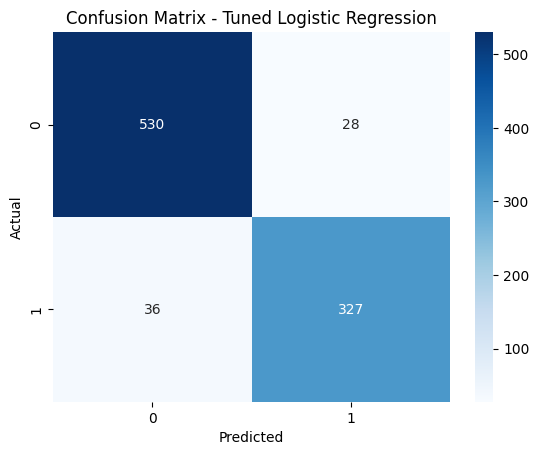

In [18]:
cm = confusion_matrix(y_test, y_pred_best_log_reg)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Tuned Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
print(classification_report(y_test, y_pred_best_log_reg))

              precision    recall  f1-score   support

           0       0.94      0.95      0.94       558
           1       0.92      0.90      0.91       363

    accuracy                           0.93       921
   macro avg       0.93      0.93      0.93       921
weighted avg       0.93      0.93      0.93       921



# 10. SVM with Different Kernels

In [20]:
kernels = ["linear", "poly", "rbf", "sigmoid"]
svm_results = []

for k in kernels:
    model = SVC(kernel=k, degree=3)

    start = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start

    y_pred_k = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred_k)
    f1_k = f1_score(y_test, y_pred_k)

    svm_results.append({
        "Kernel": k,
        "Accuracy": acc,
        "F1 Score": f1_k,
        "Training Time": train_time
    })

svm_results_df = pd.DataFrame(svm_results)
svm_results_df

,Kernel,Accuracy,F1 Score,Training Time
0,linear,0.929425,0.909344,0.290445
1,poly,0.779587,0.621974,0.256227
2,rbf,0.927253,0.905501,0.155334
3,sigmoid,0.884908,0.852778,0.160219


# 11. SVM Hyperparameter Tuning

In [21]:
param_grid_svm = [
    {"kernel": ["linear"], "C": [0.1, 1, 10, 100]},
    {"kernel": ["rbf"], "C": [0.1, 1, 10, 100], "gamma": ["scale", "auto"]},
    {"kernel": ["sigmoid"], "C": [0.1, 1, 10, 100], "gamma": ["scale", "auto"]},
    {"kernel": ["poly"], "C": [0.1, 1, 10, 100], "gamma": ["scale", "auto"], "degree": [2, 3, 4]},
]

grid_svm = GridSearchCV(
    SVC(),
    param_grid_svm,
    cv=5,
    scoring="accuracy"
)

grid_svm.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_svm.best_params_)
print("Best CV Accuracy:", grid_svm.best_score_)

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Accuracy: 0.9331521739130435


# 12. Best SVM Evaluation

In [22]:
best_svm = grid_svm.best_estimator_

start = time.time()
best_svm.fit(X_train_scaled, y_train)
best_svm_train_time = time.time() - start

y_pred_best_svm = best_svm.predict(X_test_scaled)

svm_accuracy = accuracy_score(y_test, y_pred_best_svm)
svm_precision = precision_score(y_test, y_pred_best_svm)
svm_recall = recall_score(y_test, y_pred_best_svm)
svm_f1 = f1_score(y_test, y_pred_best_svm)

print("Accuracy:", svm_accuracy)
print("Precision:", svm_precision)
print("Recall:", svm_recall)
print("F1 Score:", svm_f1)
print("Training Time:", best_svm_train_time)

Accuracy: 0.9207383279044516
Precision: 0.9142857142857143
Recall: 0.8815426997245179
F1 Score: 0.8976157082748948
Training Time: 0.1550455093383789


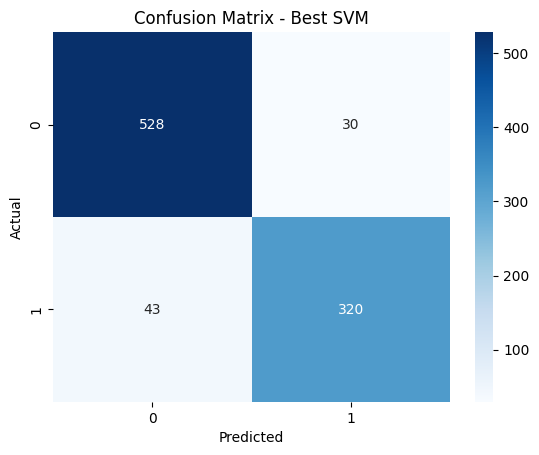

In [23]:
cm = confusion_matrix(y_test, y_pred_best_svm)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Best SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [24]:
print(classification_report(y_test, y_pred_best_svm))

              precision    recall  f1-score   support

           0       0.92      0.95      0.94       558
           1       0.91      0.88      0.90       363

    accuracy                           0.92       921
   macro avg       0.92      0.91      0.92       921
weighted avg       0.92      0.92      0.92       921



# 13. Logistic Regression vs SVM Comparison

In [25]:
comparison_df = pd.DataFrame({
    "Model": ["Tuned Logistic Regression", "Best Tuned SVM"],
    "Accuracy": [log_reg_accuracy, svm_accuracy],
    "Precision": [log_reg_precision, svm_precision],
    "Recall": [log_reg_recall, svm_recall],
    "F1 Score": [log_reg_f1, svm_f1],
    "Training Time": [best_log_reg_train_time, best_svm_train_time]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,Training Time
0,Tuned Logistic Regression,0.930510,0.921127,0.900826,0.910864,2.033884
1,Best Tuned SVM,0.920738,0.914286,0.881543,0.897616,0.155046


# 14. 5-Fold Cross-Validation Results

In [26]:
log_reg_cv_scores = cross_val_score(best_log_reg, X_train_scaled, y_train, cv=5, scoring="accuracy")
svm_cv_scores = cross_val_score(best_svm, X_train_scaled, y_train, cv=5, scoring="accuracy")

cv_results_df = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Logistic Regression Accuracy": log_reg_cv_scores,
    "SVM Accuracy": svm_cv_scores
})

cv_results_df

c:\Users\farih\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\farih\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\farih\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\farih\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\farih\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the 

,Fold,Logistic Regression Accuracy,SVM Accuracy
0,1,0.940217,0.942935
1,2,0.915761,0.932065
2,3,0.922554,0.933424
3,4,0.917120,0.921196
4,5,0.923913,0.936141


In [27]:
print("Average Logistic Regression Accuracy:", log_reg_cv_scores.mean())
print("Average SVM Accuracy:", svm_cv_scores.mean())

Average Logistic Regression Accuracy: 0.923913043478261
Average SVM Accuracy: 0.9331521739130435
